In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Buoc 1: package
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import random
import seaborn as sns
import sklearn
import tensorflow as tf
from tensorflow.keras import models
import tensorflow.keras.layers as tfl
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, Flatten, Conv2D, AveragePooling2D, MaxPooling2D, GlobalMaxPooling2D, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.initializers import random_uniform, glorot_uniform, constant, identity
from tensorflow.keras.layers import BatchNormalization

data_path = '/content/drive/MyDrive/Colab Notebooks/data/train'
class_names = os.listdir(data_path)
print(class_names)



['Acral_Lentiginous_Melanoma', 'pitting', 'blue_finger', 'Onychogryphosis', 'clubbing', 'Healthy_Nail']


In [ ]:
# Buoc 2: Xu ly du lieu
import cv2
import os
import numpy as np
import sklearn.model_selection
from tensorflow.keras.utils import to_categorical # Thêm import này

X = []
y = []

for label, name in enumerate(class_names):
    folder_path = os.path.join(data_path, name)
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Đọc ảnh
        img = cv2.imread(img_path)
        if img is None: continue

        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        img = cv2.resize(img, (224, 224))
        img = img.astype('float32')

        X.append(img)
        y.append(label)

X = np.array(X)
y = np.array(y)

# Chuẩn hóa dữ liệu ảnh về phạm vi [0, 1] ở đây
X = X / 255.0

y = to_categorical(y, num_classes=len(class_names))

print("X shape và dtype:", X.shape, X.dtype)
print("y shape:", y.shape)

X_train, X_test, y_train, y_test = sklearn.model_selection.train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    validation_split = 0.2 ,
    zoom_range = 0.15 ,
    rotation_range = 10 ,
    width_shift_range = 0.1 ,
    height_shift_range = 0.1 ,
    fill_mode = 'nearest'
)

test_datagen = ImageDataGenerator(
)

# fit chỉ cần cho train_datagen nếu sử dụng các phép biến đổi cần tính toán thống kê từ dữ liệu
train_datagen.fit(X_train)

print("Đã thiết lập Data Augmentation mới.")

X shape và dtype: (4178, 224, 224, 3) float32
y shape: (4178, 6)
Đã thiết lập Data Augmentation mới.


In [ ]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(3342, 224, 224, 3)
(836, 224, 224, 3)
(3342, 6)
(836, 6)


### Tăng cường dữ liệu (Data Augmentation)

Để chống lại hiện tượng quá khớp (overfitting) và giúp mô hình tổng quát hóa tốt hơn, chúng ta sẽ áp dụng kỹ thuật tăng cường dữ liệu. Keras cung cấp `ImageDataGenerator` để dễ dàng thực hiện các phép biến đổi ngẫu nhiên trên hình ảnh trong quá trình huấn luyện.

Bây giờ, chúng ta cần huấn luyện lại mô hình sử dụng `datagen` thay vì trực tiếp `X_train` và `y_train`.

In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Add, Dense, Activation, ZeroPadding2D, Flatten, Conv2D, MaxPooling2D, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.initializers import glorot_uniform
from tensorflow.keras.layers import BatchNormalization

def BasicBlock(X, filters, strides=1):
    """
    Khối BasicBlock chuẩn của ResNet-34 (2 lớp Conv 3x3)
    """
    X_shortcut = X

    # Lớp Conv thứ nhất
    X = Conv2D(filters=filters, kernel_size=(3, 3), strides=(strides, strides), padding='same',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)

    # Lớp Conv thứ hai
    X = Conv2D(filters=filters, kernel_size=(3, 3), strides=(1, 1), padding='same',
               kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)

    # Nếu strides != 1 hoặc số channels đầu vào khác số filters đầu ra
    if strides != 1 or X_shortcut.shape[-1] != filters:
        X_shortcut = Conv2D(filters=filters, kernel_size=(1, 1), strides=(strides, strides), padding='valid',
                            kernel_initializer=glorot_uniform(seed=0))(X_shortcut)
        X_shortcut = BatchNormalization(axis=3)(X_shortcut)

    # Cộng shortcut và kích hoạt
    X = Add()([X, X_shortcut])
    X = Activation('relu')(X)
    return X

def ResNet34(input_shape=(224, 224, 3), classes=6):
    X_input = Input(input_shape)

    # Giai đoạn đầu (Stage 1)
    X = ZeroPadding2D((3, 3))(X_input)
    X = Conv2D(64, (7, 7), strides=(2, 2), padding='valid', kernel_initializer=glorot_uniform(seed=0))(X)
    X = BatchNormalization(axis=3)(X)
    X = Activation('relu')(X)
    X = MaxPooling2D((3, 3), strides=(2, 2), padding='same')(X) # Thêm padding='same' để kiểm soát kích thước chuẩn 56x56

    # Khối thứ 2 (conv2_x): Toàn bộ shortcut ở đây là Identity thuần túy, strides=1
    X = BasicBlock(X, filters=64, strides=1)
    X = BasicBlock(X, filters=64, strides=1)
    X = BasicBlock(X, filters=64, strides=1)

    # Khối thứ 3 (conv3_x): Khối đầu tiên hạ kích thước bằng strides=2
    X = BasicBlock(X, filters=128, strides=2)
    X = BasicBlock(X, filters=128, strides=1)
    X = BasicBlock(X, filters=128, strides=1)
    X = BasicBlock(X, filters=128, strides=1)

    # Khối thứ 4 (conv4_x): Khối đầu tiên hạ kích thước bằng strides=2
    X = BasicBlock(X, filters=256, strides=2)
    X = BasicBlock(X, filters=256, strides=1)
    X = BasicBlock(X, filters=256, strides=1)
    X = BasicBlock(X, filters=256, strides=1)
    X = BasicBlock(X, filters=256, strides=1)
    X = BasicBlock(X, filters=256, strides=1)

    # Khối thứ 5 (conv5_x): Khối đầu tiên hạ kích thước bằng strides=2
    X = BasicBlock(X, filters=512, strides=2)
    X = BasicBlock(X, filters=512, strides=1)
    X = BasicBlock(X, filters=512, strides=1)

    # Lớp phân loại đầu ra
    X = GlobalAveragePooling2D()(X)
    X = Dropout(0.5)(X)
    X = Dense(classes, activation='softmax', kernel_initializer=glorot_uniform(seed=0))(X)

    model = Model(inputs=X_input, outputs=X, name='ResNet34_Official')
    return model

In [ ]:
model = ResNet34(input_shape=(224,224,3), classes=6)
model.summary()

Model: "ResNet34_Official"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 112, 112,  │      9,472 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 112, 112,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 112, 112,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 56, 56,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 56, 56,    │     36,928 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 56, 56,    │          0 │ batch_normalizat… │
│                     │ 64)               │            │ max_pooling2d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 56, 56,    │          0 │ add[0][0]         │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 56, 56,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 56, 56,    │     36,928 │ activation_3[0][

 Total params: 21,313,286 (81.30 MB)

 Trainable params: 21,296,262 (81.24 MB)

 Non-trainable params: 17,024 (66.50 KB)

In [ ]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
history = model.fit(train_datagen.flow(X_train, y_train, batch_size=32),
                                  epochs=20,
                                  validation_data=test_datagen.flow(X_test, y_test, batch_size=32))

Epoch 1/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 116s 685ms/step - accuracy: 0.2681 - loss: 2.3328 - val_accuracy: 0.1459 - val_loss: 2.6202
Epoch 2/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 454ms/step - accuracy: 0.3330 - loss: 1.8776 - val_accuracy: 0.1411 - val_loss: 3.9233
Epoch 3/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 453ms/step - accuracy: 0.3836 - loss: 1.7230 - val_accuracy: 0.1483 - val_loss: 2.8553
Epoch 4/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 49s 464ms/step - accuracy: 0.4090 - loss: 1.6188 - val_accuracy: 0.1974 - val_loss: 3.5604
Epoch 5/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 457ms/step - accuracy: 0.4225 - loss: 1.5538 - val_accuracy: 0.2285 - val_loss: 4.6883
Epoch 6/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 458ms/step - accuracy: 0.4572 - loss: 1.4519 - val_accuracy: 0.2153 - val_loss: 8.4898
Epoch 7/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 50s 471ms/step - accuracy: 0.4880 - loss: 1.3996 - val_accuracy: 0.3541 - val_loss: 1.9484
Epoch 8/20
105/105 ━━━━━━━━━━━━━━━━━━━━ 48s 459ms/step - accuracy: 0.4961 - loss: 

Sau khi huấn luyện lại với Data Augmentation, chúng ta sẽ xem lại các biểu đồ độ chính xác và sai số để đánh giá sự cải thiện.

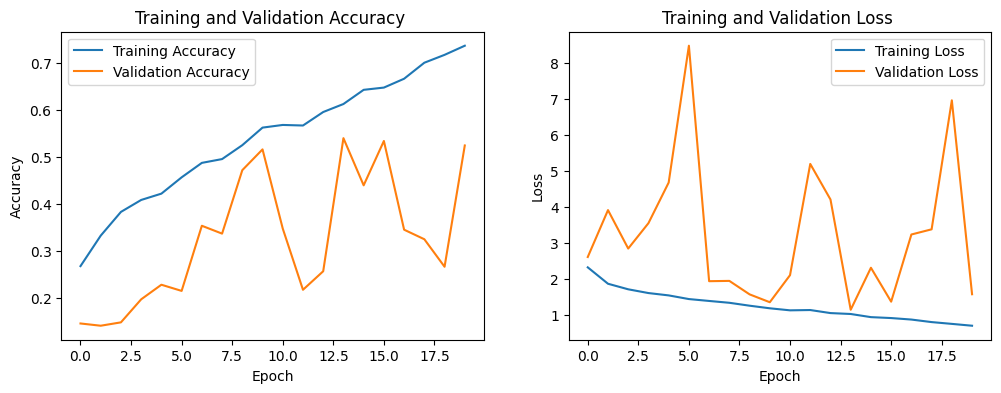

In [ ]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy ')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss ')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

### Lưu mô hình đã huấn luyện

Để sử dụng mô hình đã huấn luyện cho việc dự đoán trên dữ liệu mới mà không cần huấn luyện lại, bạn có thể lưu mô hình vào một tệp. TensorFlow cung cấp định dạng SavedModel rất tiện lợi.

In [ ]:
# Lưu mô hình
model_save_path = '/content/ResNet34_image_classifier_augmented.h5'
model.save(model_save_path)
print(f"Mô hình đã được lưu tại: {model_save_path}")

Mô hình đã được lưu tại: /content/ResNet34_image_classifier_augmented.h5


### Tải lại mô hình (Tùy chọn)

Nếu muốn tải lại mô hình để sử dụng, bạn có thể dùng đoạn code sau:

In [ ]:
# from tensorflow.keras.models import load_model
# loaded_model = load_model(model_save_path)
# print("Mô hình đã được tải lại thành công!")

In [ ]:
from tensorflow.keras.models import load_model

# Tải lại mô hình từ đường dẫn đã lưu
loaded_model = load_model(model_save_path)
print("Mô hình đã được tải lại thành công!")


Mô hình đã được tải lại thành công!


Bây giờ chúng ta có thể sử dụng `loaded_model` để dự đoán trên các hình ảnh mới hoặc dữ liệu kiểm tra.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Hình ảnh mẫu có chỉ số: 242
Nhãn thực tế: blue_finger (index: 2)
Dự đoán của mô hình: blue_finger (index: 2)
Xác suất dự đoán: 0.6845


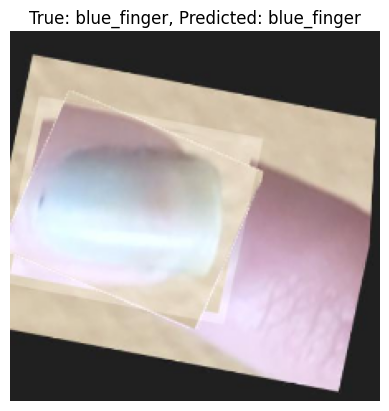

In [ ]:
from tensorflow.keras.models import load_model

# Chọn một hình ảnh ngẫu nhiên từ tập kiểm tra để dự đoán
import numpy as np
import matplotlib.pyplot as plt

sample_index = np.random.randint(0, len(X_test))
sample_image = X_test[sample_index]
sample_true_label = np.argmax(y_test[sample_index])

# Reshape hình ảnh để phù hợp với input của mô hình (thêm batch dimension)
sample_image_batch = np.expand_dims(sample_image, axis=0)

# Thực hiện dự đoán
predictions = loaded_model.predict(sample_image_batch)
predicted_class_index = np.argmax(predictions[0])

print(f"Hình ảnh mẫu có chỉ số: {sample_index}")
print(f"Nhãn thực tế: {class_names[sample_true_label]} (index: {sample_true_label})")
print(f"Dự đoán của mô hình: {class_names[predicted_class_index]} (index: {predicted_class_index})")
print(f"Xác suất dự đoán: {predictions[0][predicted_class_index]:.4f}")

# Hiển thị hình ảnh
# Hình ảnh đã được chuẩn hóa về phạm vi [0, 1] trước đó
plt.imshow(sample_image)
plt.title(f"True: {class_names[sample_true_label]}, Predicted: {class_names[predicted_class_index]}")
plt.axis('off')
plt.show()

In [ ]:
# Sử dụng test_datagen.flow để đảm bảo tiền xử lý nhất quán với tập huấn luyện
test_loss, test_accuracy = model.evaluate(test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False))
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 64ms/step - accuracy: 0.5490 - loss: 1.8881
Test loss: 1.8881
Test accuracy: 0.5490


In [ ]:
# Sử dụng test_datagen.flow để đảm bảo tiền xử lý nhất quán với tập huấn luyện
preds = model.evaluate(test_datagen.flow(X_test, y_test, batch_size=32, shuffle=False))
print("Loss = " + str(preds[0]))
print("Test Accuracy = " + str(preds[1]))

27/27 ━━━━━━━━━━━━━━━━━━━━ 2s 75ms/step - accuracy: 0.5490 - loss: 1.8881
Loss = 1.8880823850631714
Test Accuracy = 0.5490430593490601
